In [1]:
# Import core data processing and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

# Download necessary NLTK packages for text preprocessing
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Scikit-Learn tools for vectorization, splitting, modeling, and evaluation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Optional visualization
try:
    from wordcloud import WordCloud
    has_wordcloud = True
except ImportError:
    has_wordcloud = False

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [2]:
import urllib.request
import zipfile

# Download the SMS Spam Collection dataset zip file
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
urllib.request.urlretrieve(url, "smsspamcollection.zip")

# Extract the dataset
with zipfile.ZipFile("smsspamcollection.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

# Read tab-separated dataset into Pandas DataFrame
df = pd.read_csv("data/SMSSpamCollection", sep='\t', header=None, names=['label', 'text'])

# Inspect dataset structure
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())
print("\nClass Distribution (%):")
print(df['label'].value_counts(normalize=True) * 100)
df.head()

Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class Distribution (%):
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase conversion
    text = text.lower()
    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # 3. Tokenize words
    words = text.split()
    # 4. Remove stopwords and apply stemming
    cleaned_words = [ps.stem(word) for word in words if word not in stop_words]
    return ' '.join(cleaned_words)

# Apply text cleaning
df['cleaned_text'] = df['text'].apply(preprocess_text)
df.head()

,label,text,cleaned_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


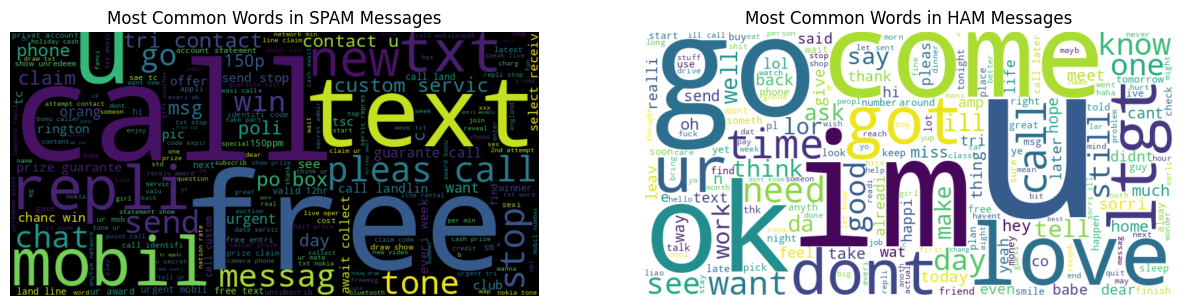

In [4]:
if has_wordcloud:
    # WordCloud for Spam
    spam_words = " ".join(df[df['label'] == 'spam']['cleaned_text'])
    wc_spam = WordCloud(width=800, height=400, background_color='black').generate(spam_words)

    # WordCloud for Ham
    ham_words = " ".join(df[df['label'] == 'ham']['cleaned_text'])
    wc_ham = WordCloud(width=800, height=400, background_color='white').generate(ham_words)

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(wc_spam, interpolation='bilinear')
    plt.title('Most Common Words in SPAM Messages')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(wc_ham, interpolation='bilinear')
    plt.title('Most Common Words in HAM Messages')
    plt.axis('off')
    plt.show()

In [5]:
# Convert categorical labels to binary numbers (ham: 0, spam: 1)
df['target'] = df['label'].map({'ham': 0, 'spam': 1})

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['cleaned_text']).toarray()
y = df['target'].values

# Train/Test Split (80/20 ratio with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (4457, 3000), X_test shape: (1115, 3000)


=== Multinomial Naive Bayes ===
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       1.00      0.81      0.90       149

    accuracy                           0.97      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



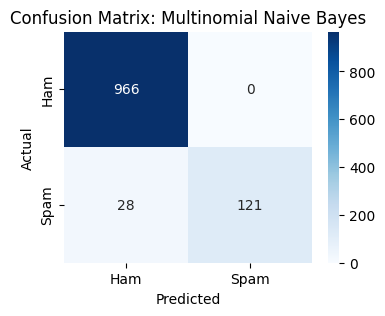

=== Logistic Regression ===
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



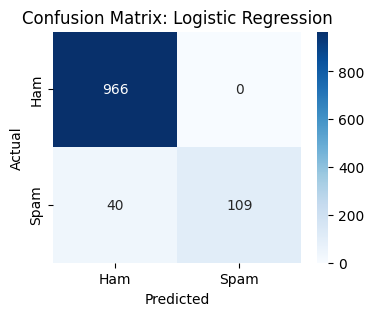


--- Model Comparison Table ---
           Multinomial Naive Bayes  Logistic Regression
Accuracy                    0.9749               0.9641
Precision                   1.0000               1.0000
Recall                      0.8121               0.7315
F1-Score                    0.8963               0.8450


In [6]:
# Initialize models
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression()
}

# Evaluate models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = [acc, prec, rec, f1]

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Performance Summary Table
df_results = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("\n--- Model Comparison Table ---")
print(df_results.round(4))